# REQUIREMENTS AND INSTALLATION

In [46]:
!pip install xgboost
!pip install shap
!pip install joblib

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import joblib
print("All Requirements installed Successfully")

All Requirements installed Successfully


# Exploratory Data Analysis

In [48]:
df=pd.read_csv("diabetes.csv")
df.head()

,id,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted
0,1,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,...,No,No,No,No,No,No,No,No,No,NO
1,2,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,3,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO
3,4,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,5,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


**MISSING VALUES**

In [49]:
print(f"DATASET SHAPE : {df.shape}\n")
print(f"COLUMNS TYPES :\n{df.dtypes.value_counts()}\n")
missing=(df=='?').sum()
missing=missing[missing>0].sort_values(ascending=False)
print(f"Columns With Missing Values :\n{missing}\n")
print(f"Weighted columns \n{(df["weight"]=='?').sum()}/{len(df)}")

DATASET SHAPE : (101766, 51)

COLUMNS TYPES :
object    37
int64     14
Name: count, dtype: int64

Columns With Missing Values :
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

Weighted columns 
98569/101766


**READMISSION - EDA**

TARGET - READMITTED

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Rows: 101766


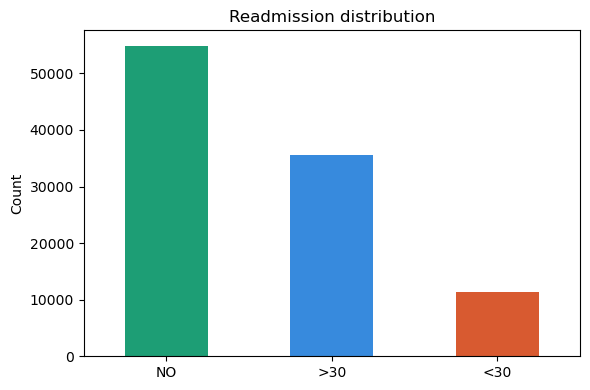

In [50]:
print("TARGET - READMITTED")
print(f"\n{df["readmitted"].value_counts()}")
print(f"\nRows: {len(df)}")

plt.figure(figsize=(6,4))
colors = ['#1D9E75', '#378ADD', '#D85A30']
df["readmitted"].value_counts().plot(kind="bar", color=colors, edgecolor="none")
plt.title('Readmission distribution')
plt.xlabel('')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**AGE GAP - EDA**

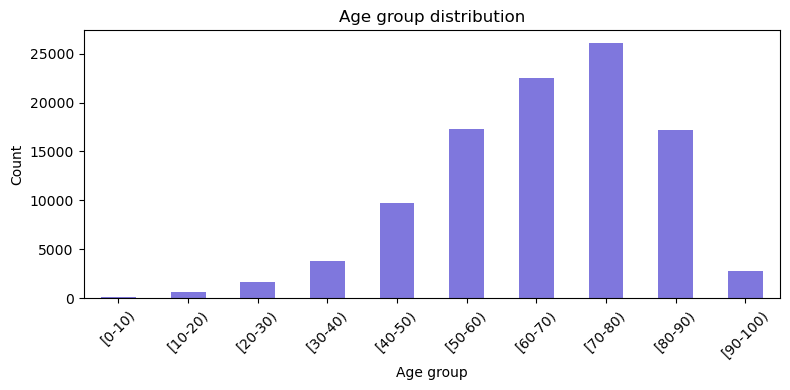

In [51]:
plt.figure(figsize=(8,4))
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)','[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_counts = df['age'].value_counts().reindex(age_order)
age_counts.plot(kind='bar', color='#7F77DD', edgecolor='none')
plt.title('Age group distribution')
plt.xlabel('Age group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**GENDER SPLIT - EDA**

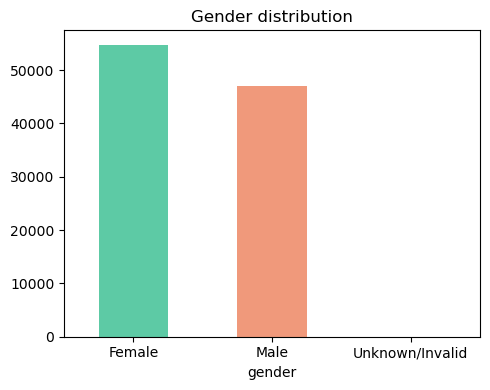

In [52]:
plt.figure(figsize=(5,4))
df['gender'].value_counts().plot(kind='bar', color=['#5DCAA5','#F0997B'], edgecolor='none')
plt.title('Gender distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Numerical columns desc**

Numerical column stats:
       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count         101766.00           101766.00       101766.00        101766.00   
mean               4.40               43.10            1.34            16.02   
std                2.99               19.67            1.71             8.13   
min                1.00                1.00            0.00             1.00   
25%                2.00               31.00            0.00            10.00   
50%                4.00               44.00            1.00            15.00   
75%                6.00               57.00            2.00            20.00   
max               14.00              132.00            6.00            81.00   

       number_diagnoses  
count         101766.00  
mean               7.42  
std                1.93  
min                1.00  
25%                6.00  
50%                8.00  
75%                9.00  
max               16.00  


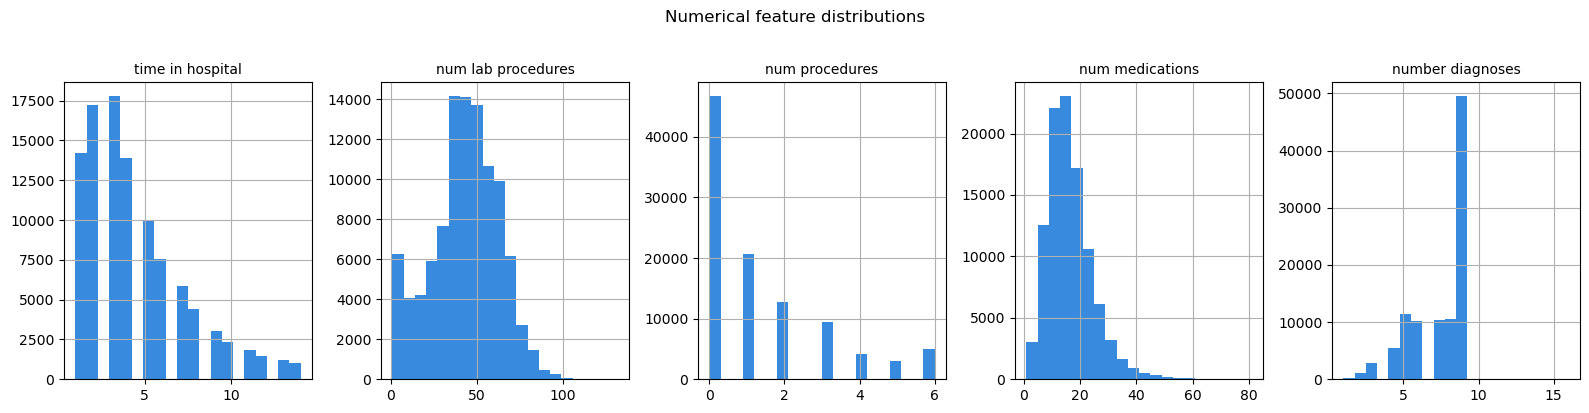

In [53]:
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_diagnoses']
print("Numerical column stats:")
print(df[num_cols].describe().round(2))
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    df[col].hist(ax=ax, bins=20, color='#378ADD', edgecolor='none')
    ax.set_title(col.replace('_', ' '), fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Numerical feature distributions', y=1.02)
plt.tight_layout()
plt.show()

**Readmitted By Age Group**

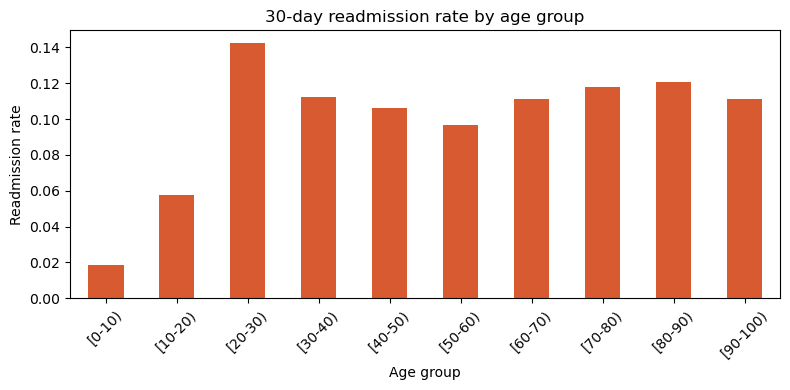

In [54]:
readmit_by_age = df[df['readmitted'] == '<30'].groupby('age').size() / df.groupby('age').size()
readmit_by_age = readmit_by_age.reindex(age_order)

plt.figure(figsize=(8,4))
readmit_by_age.plot(kind='bar', color='#D85A30', edgecolor='none')
plt.title('30-day readmission rate by age group')
plt.xlabel('Age group')
plt.ylabel('Readmission rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Data Cleaning and Synthetic Oversampling (SMOTE)

**Drop Unwanted Cols**

In [55]:
col_to_drop=['encounter_id', 'patient_nbr', 'examide', 'citoglipton', 'weight']
df.drop(columns=col_to_drop,inplace=True,errors="ignore")
print(f"Dataset Shape After Drop : {df.shape}")

Dataset Shape After Drop : (101766, 46)


**REPLACING AND DROPING Nan**

In [56]:
df.replace('?',np.nan,inplace=True)
df.dropna(subset=['diag_1', 'diag_2', 'diag_3'], inplace=True)
cat_col_now=df.select_dtypes(include="object").columns
df[cat_col_now]=df[cat_col_now].fillna("Unknown")
print(f"Shape after handling missing values: {df.shape}")
print(f"Any nulls remaining: {df.isnull().any().any()}")

Shape after handling missing values: (100244, 46)
Any nulls remaining: False


**Creating Binary Target**

In [57]:
df['Target']=(df["readmitted"]=="<30").astype(int)
df.drop(columns=['readmitted'],inplace=True,errors="ignore")
print("Target distribution after binarization:")
print(df['Target'].value_counts())
print(f"Positive class (readmitted <30d): {df['Target'].mean()*100:.1f}%")

Target distribution after binarization:
Target
0    88994
1    11250
Name: count, dtype: int64
Positive class (readmitted <30d): 11.2%


**Label Encoding**

In [58]:
cat_col_final=df.select_dtypes(include="object").columns
print(f"Encoding {len(cat_col_final)} Categorical Columns :\n{list(cat_col_final)}")

Encoding 33 Categorical Columns :
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide.metformin', 'glipizide.metformin', 'glimepiride.pioglitazone', 'metformin.rosiglitazone', 'metformin.pioglitazone', 'change', 'diabetesMed']


In [61]:
le=LabelEncoder()
for col in  cat_col_final:
    df[col]=le.fit_transform(df[col].astype(str))
print("Encoding Done")
print(f"Shape After Encoding {df.shape}")
df.head(3)

Encoding Done
Shape After Encoding (100244, 46)


,id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,tolazamide,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,Target
1,2,2,0,1,1,1,7,3,16,66,...,0,3,1,0,0,0,0,0,1,0
2,3,0,0,2,1,1,7,2,16,66,...,0,1,1,0,0,0,0,1,1,0
3,4,2,1,3,1,1,7,2,16,66,...,0,3,1,0,0,0,0,0,1,0


**Spliting Before SMOTE**

In [66]:
X=df.drop(columns=['Target'])
Y=df['Target']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"\nTrain class distribution:")
print(Y_train.value_counts())

Train size: (80195, 45)
Test size:  (20049, 45)

Train class distribution:
Target
0    71195
1     9000
Name: count, dtype: int64


**Apply SMOTE**

In [69]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, Y_train)
print("After SMOTE — training set : ")
print(f"Class 0 (not readmitted): {(y_train_sm == 0).sum()}")
print(f"Class 1 (readmitted <30d): {(y_train_sm == 1).sum()}")
print(f"Total training rows: {len(X_train_sm)}")

After SMOTE — training set : 
Class 0 (not readmitted): 71195
Class 1 (readmitted <30d): 71195
Total training rows: 142390


**Model Initialization**

In [77]:
models={"Logistic Regression":LogisticRegression(max_iter=1000,random_state=42),
      "Random Forest Classifier":RandomForestClassifier(n_estimators=1000,random_state=42,n_jobs=-1),
      "XGBoost":XGBClassifier(n_estimators=1000,random_state=42,eval_metric='logloss')}
result={}
trained_model={}

**Model Training using roc-auc**

In [81]:
for name,model in models.items():
    print(f"Training {name}")
    model.fit(X_train,Y_train)
    y_proba=model.predict_proba(X_test)[:,-1]
    auc=roc_auc_score(Y_test,y_proba)
    result[name]=auc
    trained_model[name]=model
    print(f"  ROC-AUC: {auc:.4f}\n")
print("All models trained.")
print(f"Best model: {max(result, key=result.get)} ({max(result.values()):.4f})")
    

Training Logistic Regression
  ROC-AUC: 0.6069

Training Random Forest Classifier
  ROC-AUC: 0.6613

Training XGBoost
  ROC-AUC: 0.6177

All models trained.
Best model: Random Forest Classifier (0.6613)


**Model Performance Visualization**

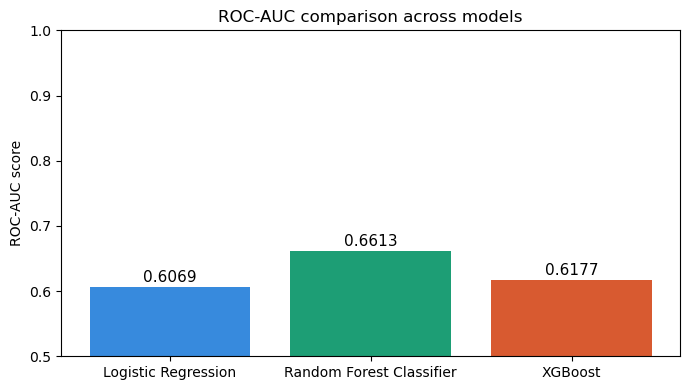

In [83]:
plt.figure(figsize=(7,4))
bars=plt.bar(result.keys(),result.values(),color=['#378ADD', '#1D9E75', '#D85A30'], edgecolor='none')
for bar, val in zip(bars, result.values()):
    plt.text(bar.get_x() + bar.get_width()/2,bar.get_height() + 0.003,f'{val:.4f}', ha='center', va='bottom', fontsize=11)

plt.ylim(0.5, 1.0)
plt.title('ROC-AUC comparison across models')
plt.ylabel('ROC-AUC score')
plt.tight_layout()
plt.show()

**Model Accuracy Score Visualization**

=== Random Forest Classifier ===
                 precision    recall  f1-score   support

 Not readmitted       0.89      1.00      0.94     17799
Readmitted <30d       0.65      0.00      0.01      2250

       accuracy                           0.89     20049
      macro avg       0.77      0.50      0.48     20049
   weighted avg       0.86      0.89      0.84     20049



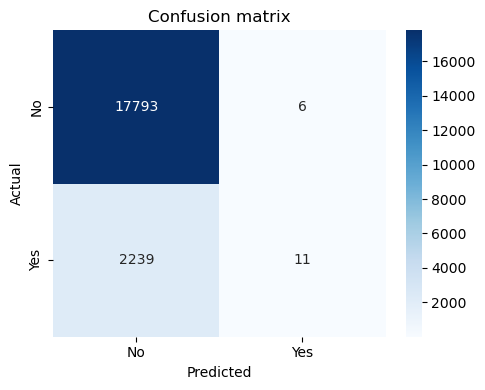

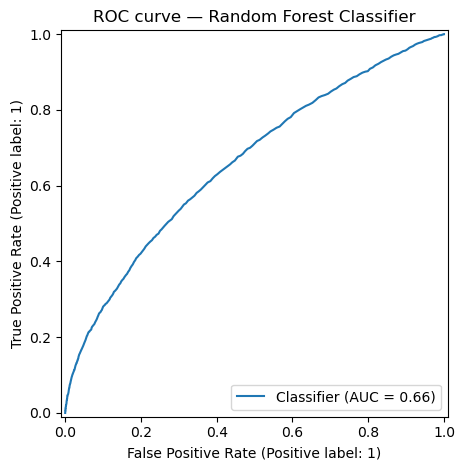

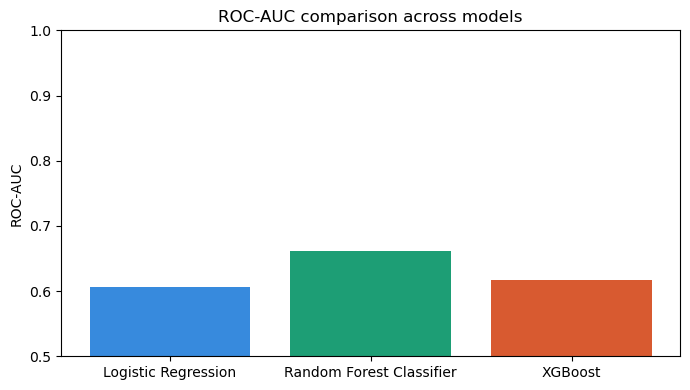

In [88]:
best_model_name = max(result, key=result.get)
best_model = trained_model[best_model_name]
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
print(f"=== {best_model_name} ===")
print(classification_report(Y_test, y_pred, target_names=['Not readmitted', 'Readmitted <30d']))


plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(Y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title('Confusion matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


RocCurveDisplay.from_predictions(Y_test, y_proba)
plt.title(f'ROC curve — {best_model_name}')
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,4))
plt.bar(result.keys(), result.values(), color=['#378ADD','#1D9E75','#D85A30'])
plt.ylim(0.5, 1.0)
plt.title('ROC-AUC comparison across models')
plt.ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

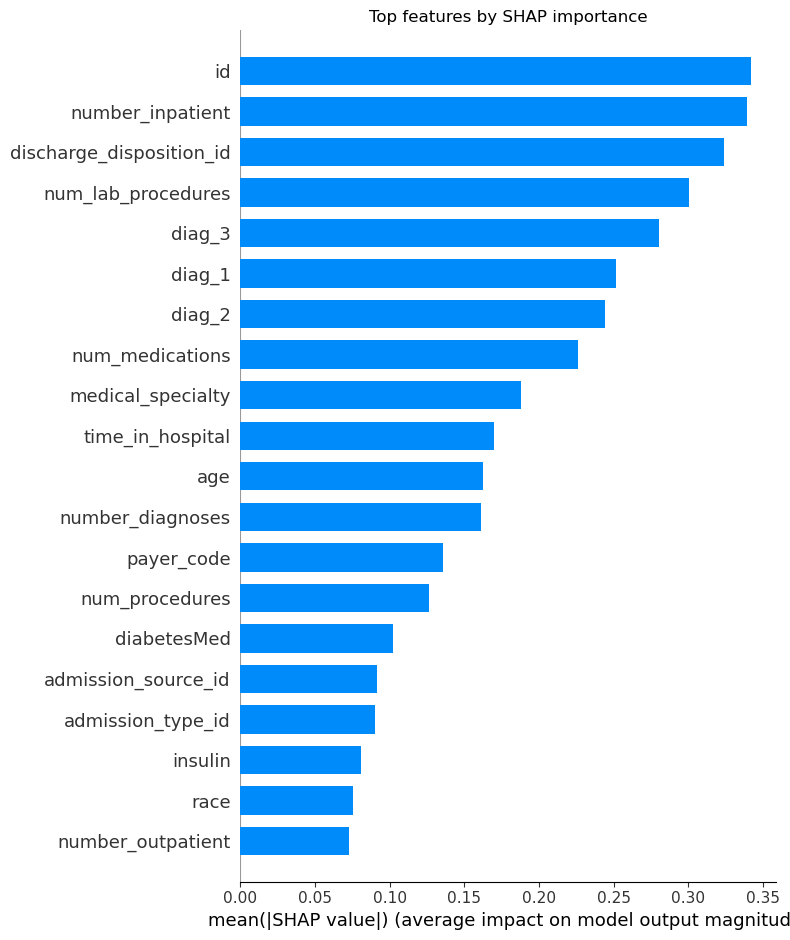

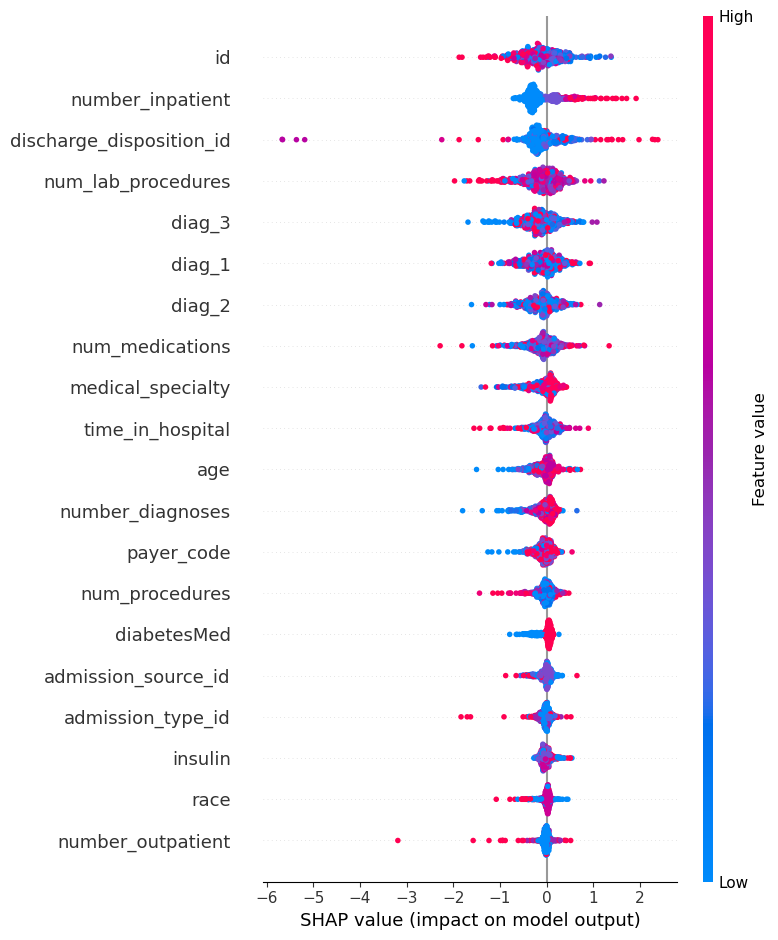

Model saved as diabetes_readmission_model.pkl

Notebook complete! Ready to push to GitHub.


In [89]:
xgb_model = trained_model['XGBoost']
explainer = shap.TreeExplainer(xgb_model)
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('Top features by SHAP importance')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()
joblib.dump(xgb_model, 'diabetes_readmission_model.pkl')
print("Model saved as diabetes_readmission_model.pkl")